<a href="https://colab.research.google.com/github/Kapilbhadu0017/Deep-Learning-Projects/blob/main/DLbasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
def sigmoid(x):
  return 1/(1 + np.exp(-x))

sigmoid(1)

np.float64(0.7310585786300049)

In [ ]:
X = np.array([7,2,25])
actual = 85

#weights
w1,w2,w3,w4,w5,w6,w7,w8 = 1,1.16,1,0.9,1,0.6,0.1,1.5
b1, b2, b3 = 5, -4, 12

In [ ]:
def forward_propogation(X):
  z1 = X[0]*w1 + X[1]*w3 + X[2]*w5 + b1
  z2 = X[0]*w2 + X[1]*w4 + X[2]*w6 + b2
  g1 = sigmoid(z1)
  g2 = sigmoid(z2)
  y_pred = g1*w7 + g2*w8 +b3
  return g1, g2, y_pred

In [ ]:
g1, g2, y_pred = forward_propogation(X)

cost = (actual - y_pred)**2

In [ ]:
def backward_propogation(X, y, g1, g2, y_pred):
  dc_dypred = 2*(y_pred - y)
  dc_dw7 = dc_dypred * g1
  dc_dw8 = dc_dypred * g2
  dc_db3 = dc_dypred
  dypred_dg1 = w7
  dypred_dg2 = w8
  dg1_dz1 = g1 * (1 - g1)
  dg2_dz2 = g2 * (1 - g2)
  dz1_dw1 = X[0]
  dz1_dw3 = X[1]
  dz1_dw5 = X[2]
  dz2_dw2 = X[0]
  dz2_dw4 = X[1]
  dz2_dw6 = X[2]
  dc_dw1 = dc_dypred * dypred_dg1 * dg1_dz1 * dz1_dw1
  dc_dw2 = dc_dypred * dypred_dg2 * dg2_dz2 * dz2_dw2
  dc_dw3 = dc_dypred * dypred_dg1 * dg1_dz1 * dz1_dw3
  dc_dw4 = dc_dypred * dypred_dg2 * dg2_dz2 * dz2_dw4
  dc_dw5 = dc_dypred * dypred_dg1 * dg1_dz1 * dz1_dw5
  dc_dw6 = dc_dypred * dypred_dg2 * dg2_dz2 * dz2_dw6

  alpha = 0.01
  new_w1 = w1 - alpha*(dc_dw1)
  new_w2 = w2 - alpha*(dc_dw2)
  new_w3 = w3 - alpha*(dc_dw3)
  new_w4 = w4 - alpha*(dc_dw4)
  new_w5 = w5 - alpha*(dc_dw5)
  new_w6 = w6 - alpha*(dc_dw6)
  new_w7 = w7 - alpha*(dc_dw7)
  new_w8 = w8 - alpha*(dc_dw8)

  dc_db1 = dc_dypred * dypred_dg1 * dg1_dz1
  dc_db2 = dc_dypred * dypred_dg2 * dg2_dz2
  dc_db3 = dc_dypred

  new_b1 = b1 - alpha*(dc_db1)
  new_b2 = b2 - alpha*(dc_db2)
  new_b3 = b3 - alpha*(dc_db3)

  return new_w1, new_w2, new_w3, new_w4, new_w5, new_w6, new_w7, new_w8, new_b1, new_b2, new_b3

In [ ]:
i = 0
while i != 500:
  i = i+1
  w1,w2,w3,w4,w5,w6,w7,w7,b1,b2,b3 = backward_propogation(X, actual, g1, g2, y_pred)
  g1, g2, y_pred = forward_propogation(X)

In [ ]:
y_pred

np.float64(84.9965517693255)

In [1]:
# Using tensorflow - keras

In [3]:
import pandas as pd
import numpy as np
# creating my synthetic data
np.random.seed(10)

#Hours of sleep | Cups of Coffee | Travel time ----- Productivity Score

In [4]:
num_samples = 1000
X = np.random.rand(num_samples, 3) * np.array([14,10,60])
Y = np.random.rand(num_samples) * 100

In [6]:
X

array([[10.79848901,  0.20751949, 38.0188941 ],
       [10.48325436,  4.98507012, 13.48779873],
       [ 2.77288011,  7.60530712, 10.14665019],
       ...,
       [ 6.71512668,  9.12702251,  3.37056475],
       [ 9.85668999,  0.38099384,  8.28390774],
       [ 2.58224006,  7.40024933, 55.26242758]])

In [11]:
df = pd.DataFrame(X, columns= ['hours_of_sleep', 'cups_of_coffee', 'travel_time'])
df.head(4)

,hours_of_sleep,cups_of_coffee,travel_time
0,10.798489,0.207519,38.018894
1,10.483254,4.985070,13.487799
2,2.772880,7.605307,10.146650
3,1.236757,6.853598,57.203601


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [16]:
def create_custom_model():
  # input layer
  inputs = keras.Input(shape=(3,)) # inputs is a variable name for the layer, similarly x is the variable name for hidden layer

  # hidden layer - fully connected layer
  x = layers.Dense(2, activation = 'sigmoid')(inputs)

  # output layer
  outputs = layers.Dense(1, activation = 'linear')(x) # linear -> pass the data as it is, like not using an activation function

  # combine the network into a signle unit
  model = keras.Model(inputs = inputs, outputs = outputs)
  return model

In [17]:
my_first_neural_network = create_custom_model()

In [19]:
my_first_neural_network.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# we need to compile every neural network
my_first_neural_network.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.01),
                                loss = 'mean_squared_error')

In [22]:
history = my_first_neural_network.fit(X, Y, epochs = 200,
                    batch_size = 32,
                    validation_split = 0.20)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3265.2493 - val_loss: 3042.4243
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3153.4946 - val_loss: 2877.6348
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2939.8726 - val_loss: 2678.7278
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2827.6675 - val_loss: 2595.9924
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2749.2380 - val_loss: 2522.1482
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2678.1318 - val_loss: 2452.3635
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2610.1538 - val_loss: 2387.4431
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2546.4294 - val_loss: 2324.3088
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2484.5706 - val_loss: 2264.3232
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2425.3689 - val_loss: 2206.2620
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2368.2458 - val_loss: 2150.0

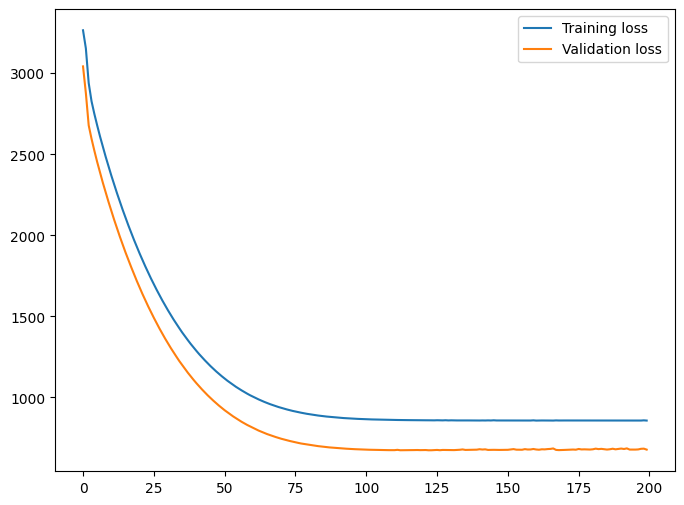

In [25]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()